In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("./monomer_binder_prediction_records.parquet")

print(df.shape)
print(df.head())
print(df["method"].value_counts())
print(df["parse_success"].value_counts())

(13200, 16)
                                                path file_type method  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb    AF2   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb    AF2   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb    AF2   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb    AF2   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...      .pdb    AF2   

      complex_name               prediction_id  rank binder_chain_id  \
0  amber-bat-stone  model_5_multimer_v3_pred_0     1               A   
1  amber-bat-stone  model_3_multimer_v3_pred_0     2               B   
2  amber-bat-stone  model_4_multimer_v3_pred_0     3               B   
3  amber-bat-stone  model_2_multimer_v3_pred_0     4               B   
4  amber-bat-stone  model_1_multimer_v3_pred_0     5               B   

   binder_length                                    binder_sequence     score  \
0             63  SEIDEKLKQFLAQLEAE

In [5]:
df2 = pd.read_parquet("rank1_structures.parquet")
print(df2.shape)
print(df2.head())
print(df2["method"].value_counts())

(3606, 9)
                                     binder_sequence      method  \
0  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...         AF2   
1  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...         AF3   
2  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...     Boltz-2   
3  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...      Chai-1   
4  AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...  HelixFold3   

                                                path  rank file_type  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...     1      .pdb   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...     1      .cif   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...     1      .cif   
3  /home/postyr/Assessing-AI-Scoring-Accuracy-for...     1      .cif   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...     1      .cif   

  binder_chain_id target_chain_id     score       score_name  
0               B               A  0.903964         iptm+ptm  
1               A     

In [10]:
pred_df = pd.read_parquet("./monomer_vs_multimer_binder_rmsd.parquet")
df_csv = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results_old/AdaptyvBio/contest_2_round_2_metrics_summary.csv")


In [16]:
rmsd_merged = pred_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
rmsd_merged = rmsd_merged.drop(columns=["sequence"])

In [17]:
plot_rmsd = rmsd_merged[rmsd_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

In [21]:
print(plot_rmsd.head())

                                     binder_sequence   method  \
0  MKEAEERERKRREEEERARREAAEAAERAARGAAARAAAEAALAAA...      AF3   
1                     QLFHEQIVNEFDNYSNKILKFGRSVFSRKQ      AF3   
2      DGYPPSNIMTRNPEENIDQFLEKQLYKMNLFAREDQQMQQYDRDP      AF3   
4  DAAARHAHRQRVLAESAFDIGRAIHLGLGPDKEEESEPFYAAVAAY...  Boltz-2   
5  EQEKADVINEIAKAGKEKGLSLTEIADKQGEALAGTLEEAKKILEE...  Boltz-2   

                                        path_monomer file_type_monomer  \
0  /home/postyr/Assessing-AI-Scoring-Accuracy-for...              .cif   
1  /home/postyr/Assessing-AI-Scoring-Accuracy-for...              .cif   
2  /home/postyr/Assessing-AI-Scoring-Accuracy-for...              .cif   
4  /home/postyr/Assessing-AI-Scoring-Accuracy-for...              .cif   
5  /home/postyr/Assessing-AI-Scoring-Accuracy-for...              .cif   

             prediction_id  rank_monomer binder_chain_id_monomer  \
0          seed-0_sample-2             1                       A   
1          seed-0_sample-0  

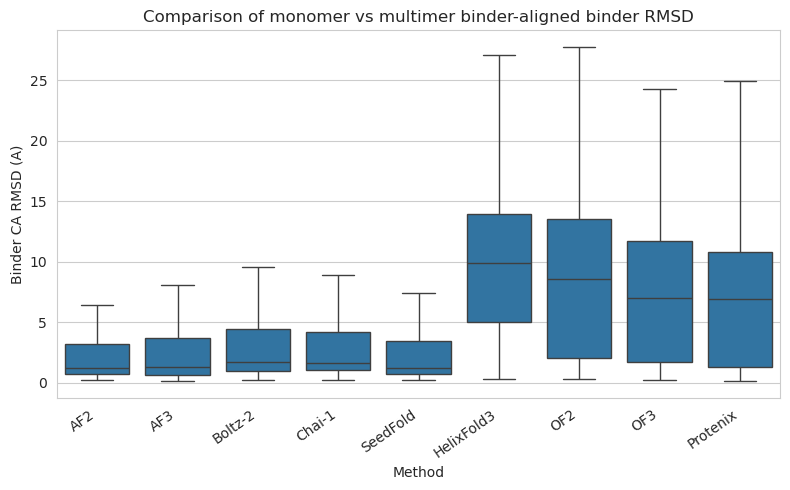

In [15]:
order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=pred_df,
    x="method",
    y="binder_ca_rmsd",
    order=order,
    showfliers=False,
)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Binder CA RMSD (A)")
plt.xlabel("Method")
plt.title("Comparison of monomer vs multimer binder-aligned binder RMSD")
plt.tight_layout()
plt.show()

In [39]:
df = plot_rmsd.copy()

df = df[df["rmsd_status"].eq("ok")].copy()
df = df[df["binder_ca_rmsd"].notna()].copy()

df["binding_label"] = df["binding"].map({
    True: "Binder",
    False: "Non-binder",
})

df["binding_label"].value_counts(dropna=False)

method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]

binding_order = ["Non-binder", "Binder"]

palette = {
    "Binder": "#DD8452",   # orange    
    "Non-binder": "#4C72B0"   # blue
}

summary = (
    df.groupby(["method", "binding_label"])["binder_ca_rmsd"]
    .agg(
        n="count",
        median="median",
        mean="mean",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        min="min",
        max="max",
    )
    .assign(iqr=lambda x: x["q3"] - x["q1"])
    .reset_index()
)

summary.sort_values(["method", "binding_label"])

,method,binding_label,n,median,mean,q1,q3,min,max,iqr
0,AF2,Binder,27,1.185928,1.583451,0.952716,2.071105,0.608031,3.665435,1.118389
1,AF2,Non-binder,170,1.288306,3.481825,0.801701,3.470367,0.238877,22.431992,2.668666
2,AF3,Binder,27,1.663294,2.077429,0.890252,2.645878,0.438749,10.102645,1.755625
3,AF3,Non-binder,170,1.689069,3.295135,0.803231,3.805555,0.236873,21.778627,3.002325
4,Boltz-2,Binder,27,1.695619,2.122817,1.174795,2.411165,0.536486,5.932479,1.236369
5,Boltz-2,Non-binder,170,2.168032,3.620684,1.093943,5.611531,0.272191,14.654590,4.517587
6,Chai-1,Binder,27,1.499029,1.903686,1.073552,2.585027,0.391141,4.750095,1.511476
7,Chai-1,Non-binder,170,1.807929,3.416256,1.054774,4.441329,0.268754,19.780835,3.386555
8,HelixFold3,Binder,27,9.676289,9.285851,8.212425,11.285550,0.463090,15.877406,3.073125
9,HelixFold3,Non-binder,170,8.632403,7.596936,4.447886,10.656733,0.347898,19.982623,6.208846


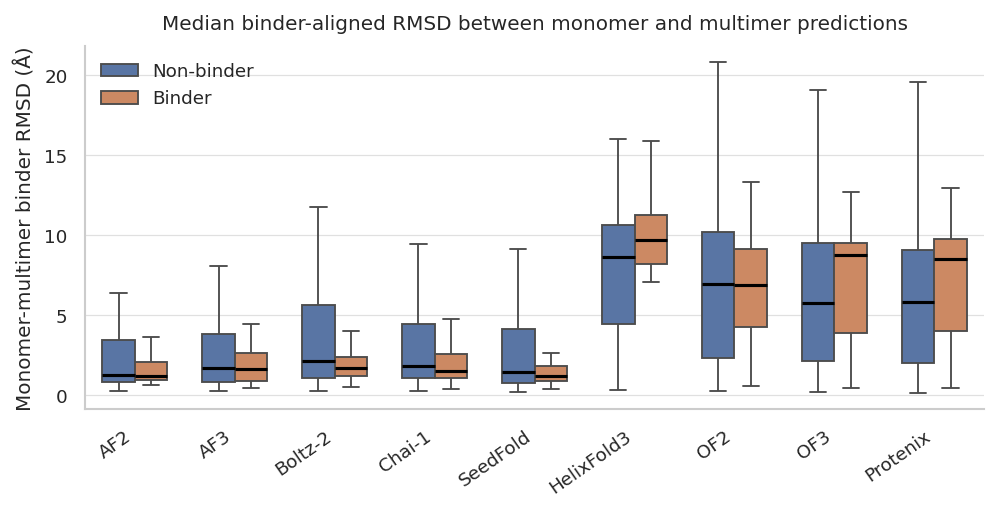

In [43]:
fig, ax = plt.subplots(figsize=(max(5.0, 0.75 * len(method_order)), 3.5))

sns.boxplot(
    data=df,
    x="method",
    y="binder_ca_rmsd",
    hue="binding_label",
    order=method_order,
    hue_order=binding_order,
    palette=palette,
    showfliers=False,
    width=0.65,
    linewidth=0.9,
    medianprops={"color": "black", "linewidth": 1.5},
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Monomer-multimer binder RMSD (Å)")
ax.set_title("Median binder-aligned RMSD between monomer and multimer predictions", pad=8)

ax.tick_params(axis="x", rotation=35)
for tick in ax.get_xticklabels():
    tick.set_horizontalalignment("right")

sns.despine(ax=ax)
ax.grid(axis="y", color="0.88", linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, title="")

fig.tight_layout()
plt.show()

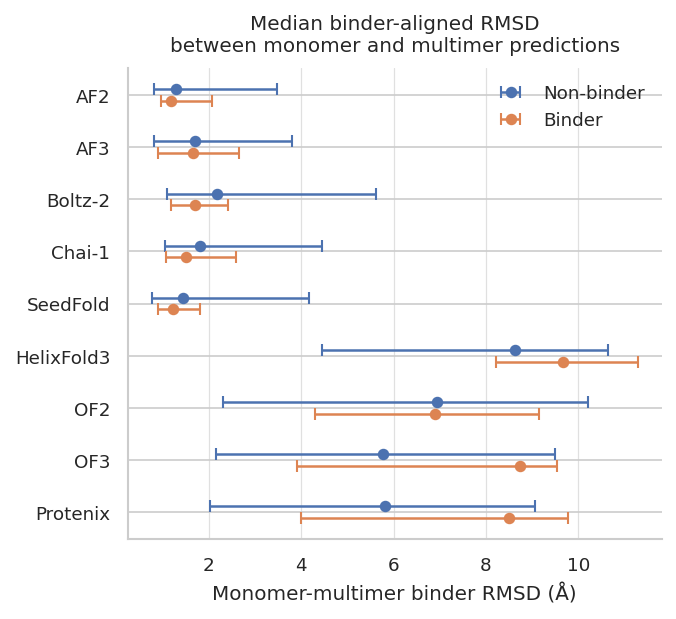

In [45]:
plot_summary = summary[
    summary["binding_label"].isin(binding_order)
].copy()

fig, ax = plt.subplots(figsize=(4.6, max(2.8, 0.38 * len(method_order) + 0.8)))

y_positions = {method: i for i, method in enumerate(method_order)}
offsets = {
    "Binder": 0.11,
    "Non-binder": -0.11,
}

for label in binding_order:
    sub = plot_summary[plot_summary["binding_label"] == label].copy()
    sub["y"] = sub["method"].map(y_positions) + offsets[label]

    xerr = np.vstack([
        sub["median"] - sub["q1"],
        sub["q3"] - sub["median"],
    ])

    ax.errorbar(
        sub["median"],
        sub["y"],
        xerr=xerr,
        fmt="o",
        color=palette[label],
        ecolor=palette[label],
        elinewidth=1.2,
        capsize=3,
        markersize=4.5,
        label=label,
    )

ax.set_yticks(range(len(method_order)))
ax.set_yticklabels(method_order)
ax.invert_yaxis()

ax.set_xlabel("Monomer-multimer binder RMSD (Å)")
ax.set_ylabel("")
ax.set_title("Median binder-aligned RMSD\nbetween monomer and multimer predictions", pad=8)

sns.despine(ax=ax)
ax.grid(axis="x", color="0.88", linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, title="")

fig.tight_layout()
plt.show()